In [3]:
# cell 1 — mock data to test before real data is ready
import pandas as pd, numpy as np
from datetime import datetime, timedelta

base = datetime(2001, 1, 1)
rows = []
for _ in range(500):
    rows.append({
        'sender':    f'u{np.random.randint(0,20)}',
        'recipient': f'u{np.random.randint(0,20)}',
        'timestamp': base + timedelta(hours=np.random.randint(0, 720)),
        'month':     '2001-01'
    })
df_email = pd.DataFrame(rows)
df_email['month'] = df_email['timestamp'].dt.to_period('M').astype(str)

In [4]:
# cell 2 — build a quick snapshot dict
import networkx as nx

snapshots = {}
for period, group in df_email.groupby('month'):
    G = nx.from_pandas_edgelist(group, 'sender', 'recipient',
                                 create_using=nx.DiGraph())
    snapshots[period] = G

In [5]:
# cell 3 — run it
import sys
sys.path.append('../')
from src.analysis.temporal_betweenness import compute_tb_series

tb_df = compute_tb_series(df_email, snapshots)
print(tb_df.shape)
tb_df.head()

(20, 1)


,2001-01
u0,16.000000
u11,545.999999
u15,495.999999
u6,343.999999
u12,97.000000


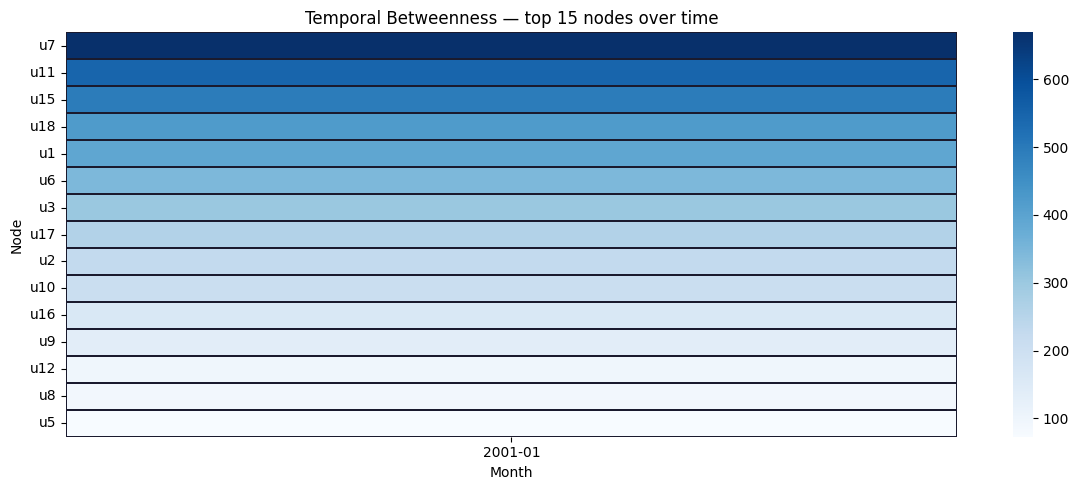

In [6]:
# cell 4 — heatmap viz
import matplotlib.pyplot as plt
import seaborn as sns

top_nodes = tb_df.max(axis=1).nlargest(15).index
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(tb_df.loc[top_nodes], cmap='Blues', ax=ax,
            linewidths=0.3, linecolor='#1a1a2e')
ax.set_title('Temporal Betweenness — top 15 nodes over time')
ax.set_xlabel('Month')
ax.set_ylabel('Node')
plt.tight_layout()
plt.show()